- DataSet From Kaggele

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


: 

In [8]:
df = pd.read_csv('mcus.csv')

Doing EDA

In [9]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [10]:
df.isnull().sum()

Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

In [11]:
df['Gender'].value_counts()

Gender
Male      7595
Female    7484
Name: count, dtype: int64

In [12]:
df.shape

(15079, 5)

In [13]:
df.describe(include = 'all')


,Customer ID,Age,Gender,Annual Income,Spending Score
count,15079,15079.000000,15079,15079.000000,15079.000000
unique,15079,NaN,2,NaN,NaN
top,d410ea53-6661-42a9-ad3a-f554b05fd2a7,NaN,Male,NaN,NaN
freq,1,NaN,7595,NaN,NaN
mean,NaN,54.191591,NaN,109742.880562,50.591617
std,NaN,21.119207,NaN,52249.425866,28.726977
min,NaN,18.000000,NaN,20022.000000,1.000000
25%,NaN,36.000000,NaN,64141.000000,26.000000
50%,NaN,54.000000,NaN,109190.000000,51.000000
75%,NaN,72.000000,NaN,155008.000000,75.000000


In [14]:
# df.drop('Customer ID' , inplace = True , axis=1)

In [15]:
# prompt: code for finsding unique values in a df

# Assuming 'df' is your DataFrame as defined in the previous code.
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")


Unique values in column 'Customer ID': ['d410ea53-6661-42a9-ad3a-f554b05fd2a7'
 '1770b26f-493f-46b6-837f-4237fb5a314e'
 'e81aa8eb-1767-4b77-87ce-1620dc732c5e' ...
 '0e87c25a-268c-401a-8ba1-7111dcde6f1a'
 '5f388cbe-3373-4e16-b743-38f508f2249f'
 'b8b8f561-ebca-4401-8afe-544c906554ba']
Unique values in column 'Age': [30 58 62 23 24 42 27 83 37 63 25 32 51 64 19 89 65 26 21 70 39 61 79 73
 90 35 57 76 40 82 84 56 55 45 28 67 69 46 36 48 50 49 80 33 38 54 81 44
 75 60 52 72 68 31 22 71 53 18 88 74 78 59 29 34 87 20 77 41 85 86 47 43
 66]
Unique values in column 'Gender': ['Male' 'Female']
Unique values in column 'Annual Income': [151479 185088  70912 ... 112337  94312  78045]
Unique values in column 'Spending Score': [ 89  95  76  57  40  37  17  34   3  75  80  96  87  81  82  97  12  49
  36   6  45   7  15  55  23  25  52  62  66   5  43  86  39  77  29   1
  16  68   2  35  54  32  90  91  53  61  31  93  79  14  27   9  59  72
  24  20  48   4  98  67  42  65  22  63  33  10  74  13  8

- Feature Engineering

In [16]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


## Visualization

In [17]:
# Getting all Numeric Features

num_features = [feature for feature in df.columns if df[feature].dtype != 'object' ]

print(num_features)
print(len(num_features))

['Age', 'Annual Income', 'Spending Score']
3


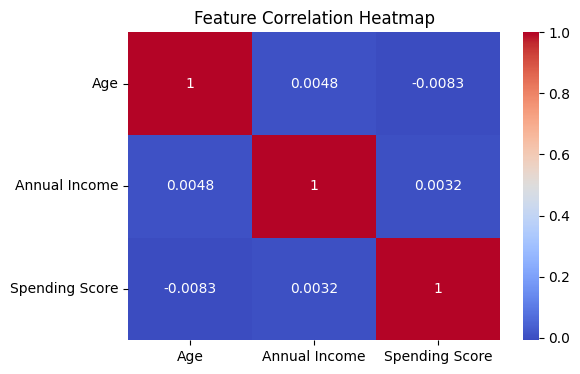

In [18]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
# correlation heatmap visualization


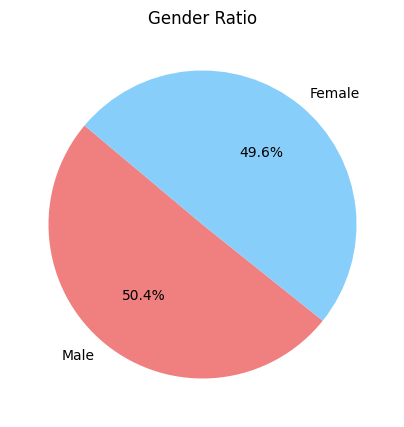

In [19]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue'])
plt.title('Gender Ratio')
plt.show()
# pie chart for Spending Score
# pie chart visualization

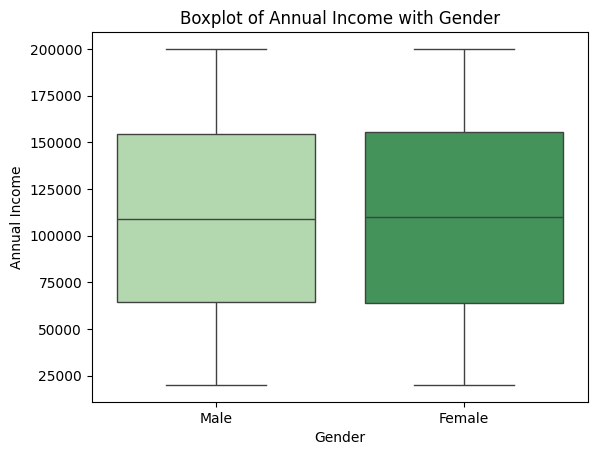

In [20]:
sns.boxplot(x = 'Gender', y = "Annual Income", data = df, palette = 'Greens')
plt.title("Boxplot of Annual Income with Gender")
plt.show()

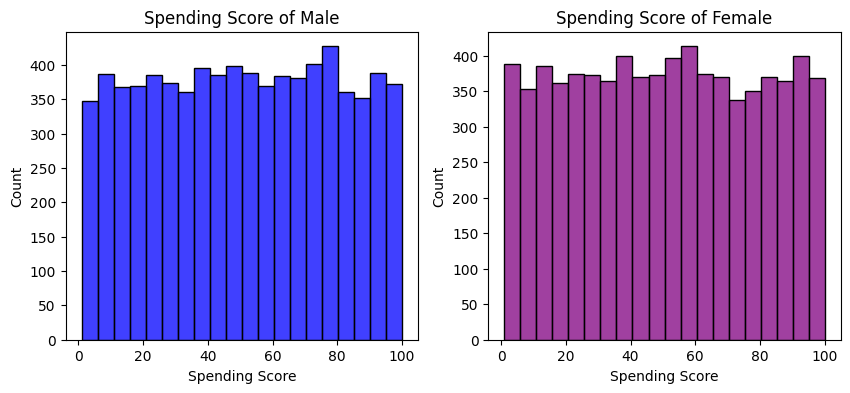

In [21]:

score_male = df[df.Gender == "Male"]["Spending Score"]
score_female = df[df.Gender != "Male"]["Spending Score"]

plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.histplot(score_male, color = "blue")
plt.title("Spending Score of Male")

plt.subplot(1,2,2)
sns.histplot(score_female, color = 'purple')
plt.title("Spending Score of Female")
plt.show()

Text(0.5, 1.0, 'Number of Males and Females')

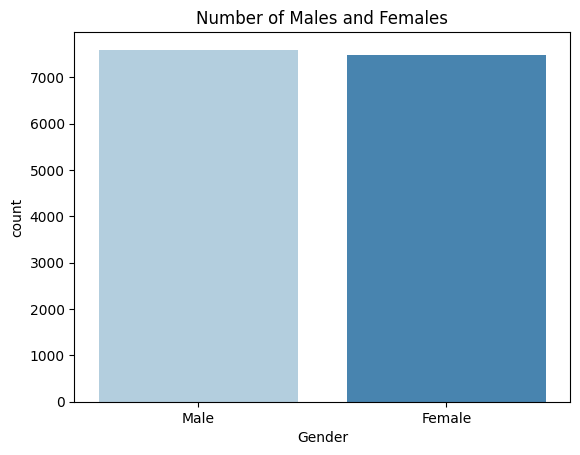

In [22]:
sns.countplot(x = 'Gender', data = df, hue = 'Gender', palette = 'Blues')
plt.title("Number of Males and Females")

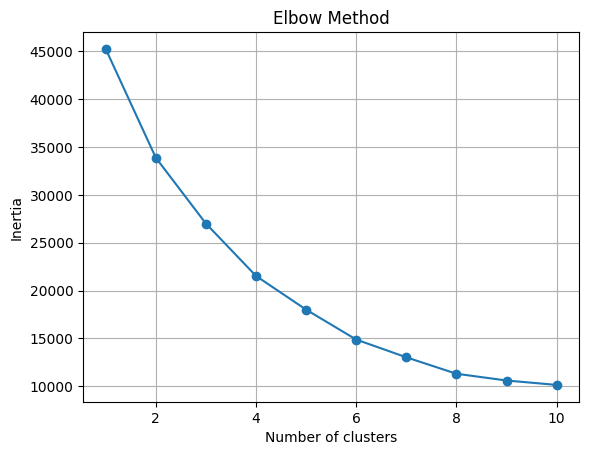

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame as defined in the previous code.
x = df[['Age', 'Annual Income', 'Spending Score']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Find optimal number of clusters (Elbow Method)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

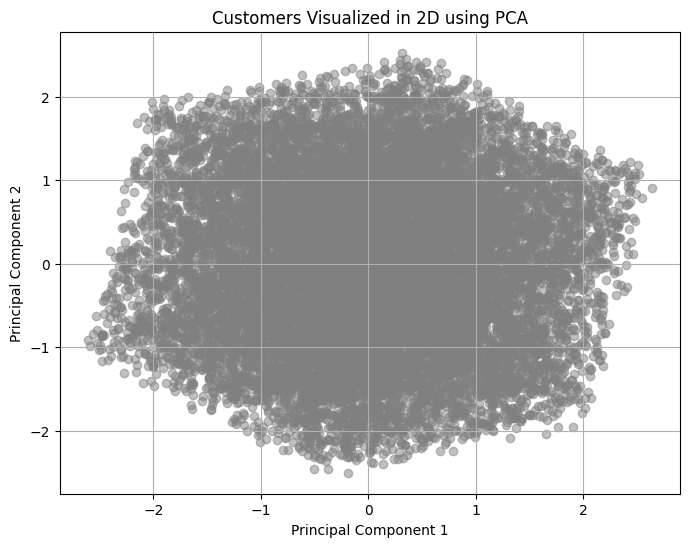

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming X_scaled already exists
# Step 1: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

# Step 2: Visualize the PCA-transformed data
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.5)
plt.title("Customers Visualized in 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()




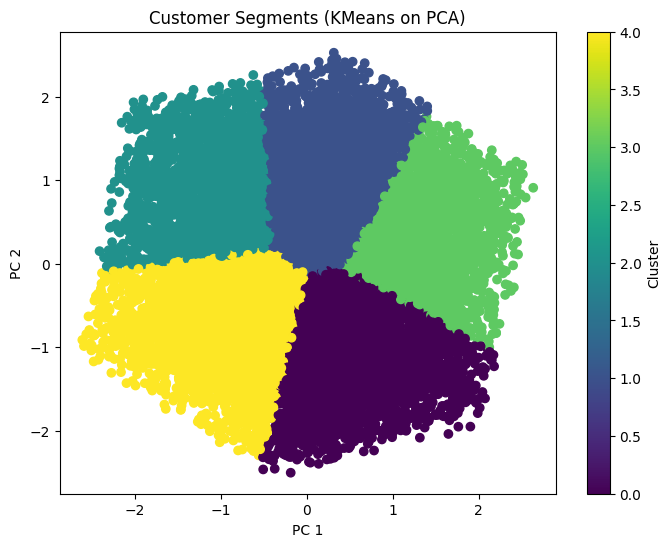

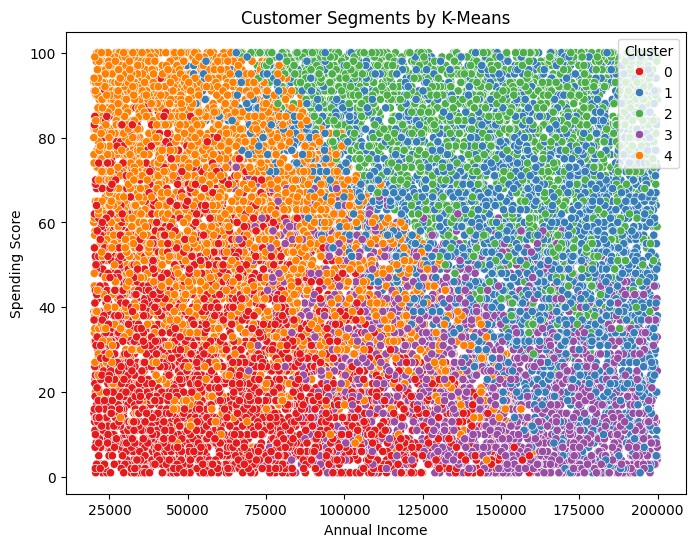

In [26]:

# Step 3: Apply KMeans on PCA data
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Step 4: Add clusters to DataFrame
df['Cluster'] = clusters

# Optional: Visualize clusters in PCA space
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("Customer Segments (KMeans on PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(label="Cluster")
plt.show()

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income', y='Spending Score',
                hue='Cluster', palette='Set1', data=df)
plt.title("Customer Segments by K-Means")
plt.show()

In [ ]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score,Cluster
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89,2
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95,4
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76,1
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57,0
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76,2


In [ ]:
# but we need to split DataSet First

from sklearn.model_selection import train_test_split
x = df[['Age', 'Annual Income', 'Spending Score']]
y = df['Cluster']

In [ ]:
x.shape

(15079, 3)

In [ ]:
x_train , x_test ,y_train ,y_test = train_test_split(x,y , test_size= 0.3 , random_state=42)
x_train .shape

(10555, 3)

In [ ]:
#Data Transforming
from sklearn.preprocessing import LabelEncoder

df  = df.copy()
# Now we will perform LabelEncoding on the Gender column.
enc = LabelEncoder()
df['Gender'] = enc.fit_transform(df['Gender'])
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score,Cluster
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,1,151479,89,2
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,0,185088,95,4
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,0,70912,76,1
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,1,55460,57,0
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,1,153752,76,2


In [ ]:
x_train.head()

,Age,Annual Income,Spending Score
3026,61,32850,79
4791,53,142230,87
4102,56,97396,96
6584,48,175553,17
13558,66,114005,24


In [ ]:
pd.DataFrame(x_train)

,Age,Annual Income,Spending Score
3026,61,32850,79
4791,53,142230,87
4102,56,97396,96
6584,48,175553,17
13558,66,114005,24
...,...,...,...
5191,76,109149,87
13418,54,58879,4
5390,26,107427,45
860,82,138788,41


Random Forest Classifier Training

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from scipy.cluster.hierarchy import dendrogram, linkage


# Standardize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# --------------------------- KMEANS CLUSTERING ---------------------------

print("🔍 KMeans GridSearch for best parameters...")
kmeans_params = {
    'n_clusters': range(2, 11),
    'init': ['k-means++'],
    'n_init': [10, 20],
    'max_iter': [300, 500],
}

kmeans = KMeans(random_state=42)
grid_search_kmeans = GridSearchCV(
    estimator=kmeans,
    param_grid=kmeans_params,
    scoring='neg_mean_squared_error',  # Silhouette score needs manual tuning
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_kmeans.fit(x_scaled)

best_kmeans = grid_search_kmeans.best_estimator_
kmeans_labels = best_kmeans.predict(x_scaled)

print(f"✅ Best KMeans Parameters: {grid_search_kmeans.best_params_}")
print(f"✅ KMeans Silhouette Score: {silhouette_score(x_scaled, kmeans_labels):.4f}")




🔍 KMeans GridSearch for best parameters...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
✅ Best KMeans Parameters: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10}


In [ ]:
# ---------------------- HIERARCHICAL CLUSTERING ----------------------

print("🔍 Trying Agglomerative Clustering with various cluster counts...")

sil_scores = {}
for n_clusters in range(2, 11):
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    sil_scores[n_clusters] = score

# Find best number of clusters
best_n = max(sil_scores, key=sil_scores.get)
print(f"✅ Best Agglomerative Clustering clusters: {best_n}")
print(f"✅ Best Silhouette Score: {sil_scores[best_n]:.4f}")

# Final Agglomerative Model
agglo = AgglomerativeClustering(n_clusters=best_n)
agglo_labels = agglo.fit_predict(x_scaled)

# --------------------- DENDROGRAM ---------------------

linked = linkage(x_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:

# --------------------- CLUSTER VISUALIZATION ---------------------

# Add cluster labels to original dataframe
df['KMeans_Cluster'] = kmeans_labels
df['Agglo_Cluster'] = agglo_labels

# KMeans cluster plot
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', palette='tab10')
plt.title("KMeans Customer Segments")
plt.show()

# Agglomerative cluster plot
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglo_Cluster', palette='Set2')
plt.title("Hierarchical (Agglomerative) Customer Segments")
plt.show()


In [ ]:
import pandas as pd
import streamlit as st
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage


# Standardize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# --------------------------- KMEANS CLUSTERING ---------------------------

# KMeans parameters
n_clusters_kmeans = st.slider('Select number of clusters for KMeans:', 2, 10, 5)

kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42)
kmeans.fit(x_scaled)
kmeans_labels = kmeans.predict(x_scaled)
silhouette_kmeans = silhouette_score(x_scaled, kmeans_labels)

st.write(f"✅ KMeans Silhouette Score: {silhouette_kmeans:.4f}")

# ---------------------- HIERARCHICAL CLUSTERING ----------------------

# Agglomerative Clustering parameters
n_clusters_agglo = st.slider('Select number of clusters for Agglomerative Clustering:', 2, 10, 5)

agglo = AgglomerativeClustering(n_clusters=n_clusters_agglo)
agglo_labels = agglo.fit_predict(x_scaled)
silhouette_agglo = silhouette_score(x_scaled, agglo_labels)

st.write(f"✅ Agglomerative Clustering Silhouette Score: {silhouette_agglo:.4f}")

# --------------------- DENDROGRAM ---------------------
linked = linkage(x_scaled, method='ward')
fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=12, ax=ax)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')

# Show dendrogram plot
st.pyplot(fig)

# --------------------- CLUSTER VISUALIZATION ---------------------
# Add the cluster labels to the original DataFrame
df['KMeans_Cluster'] = kmeans_labels
df['Agglo_Cluster'] = agglo_labels

# KMeans cluster plot
st.subheader("KMeans Cluster Plot")
fig_kmeans = plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='KMeans_Cluster', palette='tab10')
plt.title("KMeans Customer Segments")
st.pyplot(fig_kmeans)

# Agglomerative cluster plot
st.subheader("Agglomerative Cluster Plot")
fig_agglo = plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Sc', hue='Agglo_Cluster', palette='Set2')
plt.title("Hierarchical (Agglomerative) Customer Segments")
st.pyplot(fig_agglo)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import FeatureAgglomeration
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

Efficient Way Of Training THe Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Define classification models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training and evaluating {name}...")
    model.fit(x_train, y_train)

    # Predictions on training and test sets
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Evaluate on training set
    print("Training Set Performance:")
    print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Precision: {precision_score(y_train, y_train_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_train, y_train_pred, average='weighted'):.4f}")
    print(f"F1-Score: {f1_score(y_train, y_train_pred, average='weighted'):.4f}")
    print("\n")

    # Evaluate on test set
    print("Test Set Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

    # Optional: Print classification report and confusion matrix
    # print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred))
    # print("\nConfusion Matrix (Test Set):\n", confusion_matrix(y_test, y_test_pred))

    print("=" * 35)
    print("\n")

Training and evaluating Logistic Regression...
Training Set Performance:
Accuracy: 0.7327
Precision: 0.6121
Recall: 0.7327
F1-Score: 0.6655


Test Set Performance:
Accuracy: 0.7332
Precision: 0.6163
Recall: 0.7332
F1-Score: 0.6681


Training and evaluating Decision Tree...
Training Set Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


Test Set Performance:
Accuracy: 0.9719
Precision: 0.9720
Recall: 0.9719
F1-Score: 0.9719


Training and evaluating Random Forest...
Training Set Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


Test Set Performance:
Accuracy: 0.9819
Precision: 0.9819
Recall: 0.9819
F1-Score: 0.9819




In [ ]:

def predict_segment(age, income, score):
    input_data = scaler.transform([[age, income, score]])
    cluster_pred = clf.predict([[age, income, score]])
    return f"Predicted Customer Segment: Cluster {cluster_pred[0]}"

# Example Prediction
print(predict_segment(age=30, income=85, score=90))

Predicted Customer Segment: Cluster 4


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, make_scorer

# Assuming 'x' contains your features (Annual Income, Spending Score)
x = df[['Annual Income', 'Spending Score']]

# Define the parameter grid for GridSearchCV
kmeans_params = {
    'n_clusters': range(2, 11),
    'init': ['k-means++', 'random'],
    'n_init': [10, 20],
    'max_iter': [300, 500],
}

# Model list for hyperparameter tuning
randomcv_models = [  # Rename to gridcv_models for clarity
    ("KMeans", KMeans(random_state=42), kmeans_params)
]

model_params = {}

# Create a scorer function using make_scorer
silhouette_scorer = make_scorer(silhouette_score)


# Iterate over the models and perform GridSearchCV
for name, model, rf_params in randomcv_models:
    print(f"Tuning hyperparameters for {name}...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=rf_params,  # Use param_grid for GridSearchCV
        cv=5,
        scoring=silhouette_scorer,  # Use the silhouette_scorer function
        verbose=2,
        n_jobs=-1
    )
    grid_search.fit(x)  # Fit on the data

    # Save the best model and its parameters
    model_params[name] = {
        'best_model': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    }
    print(f"Best Parameters for {name}: {grid_search.best_params_}")
    print(f"Best Silhouette Score for {name}: {grid_search.best_score_}")

# No evaluation on a separate test set for clustering

Tuning hyperparameters for KMeans...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters for KMeans: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10}
Best Silhouette Score for KMeans: nan


In [ ]:
import pickle

# Load StandardScaler
with open("scaler.pkl", "wb") as f:
    scaler = pickle.load(f)

# Load PCA Transformer
with open("pca_model.pkl", "wb") as f:
    pca = pickle.load(f)

# Load KMeans Model
with open("kmeans_model.pkl", "wb") as f:
    kmeans = pickle.load(f)


In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram  # Import linkage and dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Apply Agglomerative Clustering (You'll need to import AgglomerativeClustering as well)
from sklearn.cluster import AgglomerativeClustering

# Assuming X_scaled is already defined (if not, define it appropriately)
# Standardize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Dendrogram
plt.figure(figsize=(10, 6))
link = linkage(x_scaled, method='ward')  # Now linkage is defined
dendrogram(link)  # Now dendrogram is defined
plt.title('Customer Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()


KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

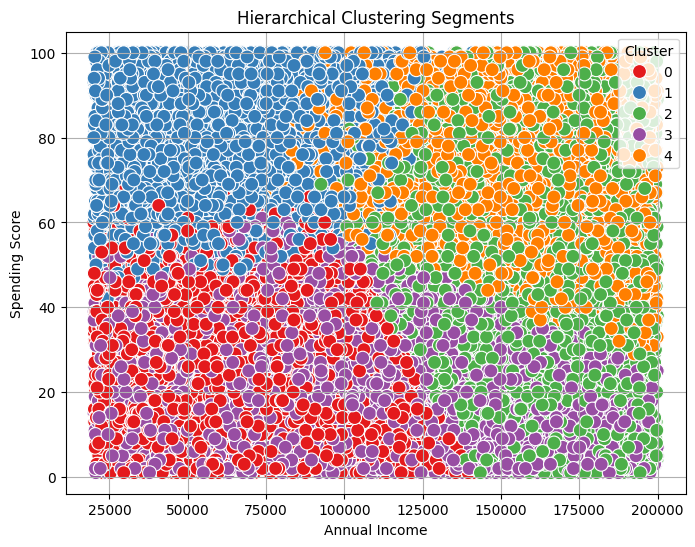

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score',
                hue='Cluster', palette='Set1', s=100)  # Change 'HC_Cluster' to 'Cluster'
plt.title('Hierarchical Clustering Segments')
plt.grid(True)
plt.show()

In [ ]:
# # Update the KMeans model in the models dictionary with the best parameters
# models = {
#     'KMeans': KMeans(init='k-means++', max_iter=300, n_clusters=2, n_init=10)
# }

# for i in range(len(list(models))):
#     model = list(models.values())[i]

#     model.fit(x_train)  # No need for y_train in clustering
#     y_train_pred = model.predict(x_train)
#     y_test_pred = model.predict(x_test)

#     # Calculate and print clustering metrics
#     silhouette = silhouette_score(x_train, y_train_pred)
#     davies_bouldin = davies_bouldin_score(x_train, y_train_pred)
#     calinski_harabasz = calinski_harabasz_score(x_train, y_train_pred)

#     print(list(models.keys())[i])

#     print('Training Set Performance')
#     print(f'Silhouette Score: {silhouette:.4f}')
#     print(f'Davies-Bouldin Index: {davies_bouldin:.4f}')
#     print(f'Calinski-Harabasz Index: {calinski_harabasz:.4f}')

#     print('--------------------------')

#     # Evaluate on test set as well (using the same metrics)
#     silhouette_test = silhouette_score(x_test, y_test_pred)
#     davies_bouldin_test = davies_bouldin_score(x_test, y_test_pred)
#     calinski_harabasz_test = calinski_harabasz_score(x_test, y_test_pred)

#     print('Test Set Performance')
#     print(f'Silhouette Score: {silhouette_test:.4f}')
#     print(f'Davies-Bouldin Index: {davies_bouldin_test:.4f}')
#     print(f'Calinski-Harabasz Index: {calinski_harabasz_test:.4f}')

#     print('=' * 35)
#     print('\n')